Name: Kashish Gupta

Enrollment Number: 10101042025

College: IGDTUW

In [13]:
import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import matplotlib.pyplot as plt

In [2]:
#1
#Load dataset
df = pd.read_csv("StudentsPerformance.csv")

In [14]:
#2
#Create Pass/Fail target using average score
df["average_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)
df["target"] = np.where(df["average_score"] >= 50, 1, 0)  # 1 = Pass, 0 = Fail

In [15]:
#3
#Encode categorical variables
df_encoded = pd.get_dummies(df.drop(columns=["average_score"]), drop_first=True)

X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

In [16]:
#4
#Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
#5
#Models
log_reg = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

models = {"Logistic Regression": log_reg, "Decision Tree": dt, "Random Forest": rf}

In [19]:
#6
#Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }

In [20]:
#7
#Cross-validation
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    print(f"{name} CV Accuracy: {cv_scores.mean():.4f}")

Logistic Regression CV Accuracy: 0.9970
Decision Tree CV Accuracy: 0.9780
Random Forest CV Accuracy: 0.9860


In [22]:
#8
#Hyperparameter tuning

#Decision Tree
dt_params = {"max_depth": [3, 5, 10, None], "min_samples_split": [2, 5, 10]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring="accuracy")
dt_grid.fit(X_train, y_train)
print("Best Decision Tree Params:", dt_grid.best_params_)

#Random Forest
rf_params = {"n_estimators": [50, 100, 200], "max_depth": [5, 10, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring="accuracy")
rf_grid.fit(X_train, y_train)
print("Best Random Forest Params:", rf_grid.best_params_)

Best Decision Tree Params: {'max_depth': 3, 'min_samples_split': 2}
Best Random Forest Params: {'max_depth': 10, 'n_estimators': 200}


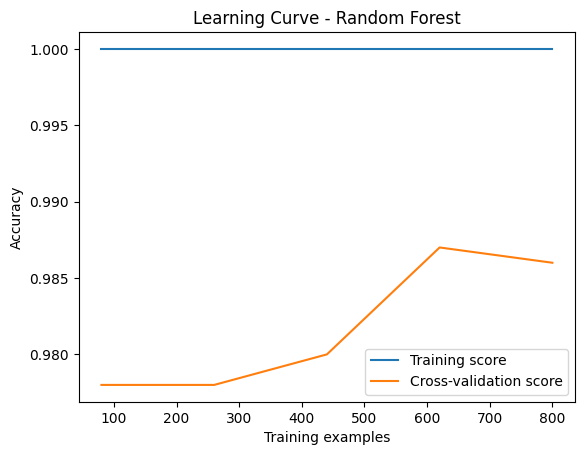

In [21]:
#9
#Learning curve plot (Random Forest as example)
train_sizes, train_scores, test_scores = learning_curve(rf_grid.best_estimator_, X, y, cv=5, scoring="accuracy")

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, test_mean, label="Cross-validation score")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.show()

In [23]:
#10
#Final Results
print("\nModel Comparison:")
for name, metrics in results.items():
    print(f"{name}: {metrics}")


Model Comparison:
Logistic Regression: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1-score': 1.0}
Decision Tree: {'Accuracy': 0.985, 'Precision': 0.9885057471264368, 'Recall': 0.9942196531791907, 'F1-score': 0.9913544668587896}
Random Forest: {'Accuracy': 0.995, 'Precision': 0.9942528735632183, 'Recall': 1.0, 'F1-score': 0.9971181556195965}


In [24]:
#END